In [1]:
from pathlib import Path

from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from numpy.typing import NDArray
import numpy as np
from scipy.interpolate import griddata

from bloodmoon.coords import angle2shift
from bloodmoon.mask import CodedMaskCamera, codedmask

import darksun as ds
from darksun.benchmarking import source_catalogue_data

ds.show.set_figures_darkbkg()

In [ ]:
def load_fits_data(path: Path, ext: int = 1) -> FITS_rec:
    """Loads the FITS file data from chosen extension."""
    return fits.getdata(path, ext=ext, header=False)

def interp(
    x: NDArray,
    y: NDArray,
    energy: NDArray,
) -> NDArray:
    """Interpolates `y` values in given `energy` values."""
    # ...
    # some preprocess (?)
    # ...
    return griddata(x, y, energy, method='linear')

def integrate(arr: NDArray, bins: NDArray) -> float:
    """Integrates input array."""
    return np.sum(arr * bins)

In [3]:
def _config_hist_values(
    x: NDArray,
    y: NDArray,
    interval: tuple[float, float],
) -> tuple[NDArray, NDArray]:
    """
    Extract `x` values in the `interval` range and respective
    values for `y`. Since x represents a binning array, len(x)
    must be equal to len(y) + 1.
    """
    low, high = interval
    band: NDArray = np.where((x >= low) & (x <= high))[0]
    return x[band], y[band[:-1]]

def extract_spectrum(
    data: FITS_rec,
    sourceID: str,
    energy_range: tuple[float, float] = (2.0, 50.0),
) -> tuple[NDArray, NDArray]:
    """
    Extracts source energy bins and spectrum values in specified `energy_range`.
    """
    data_: FITS_rec = source_catalogue_data(sourceID, data)
    energy, spectrum = _config_hist_values(
        data_['ENERGY'], data_['SPECTRUM'], energy_range,
    )
    return energy, spectrum

def integrate_spectrum(
    spectrum: NDArray,
    energy_bins: NDArray,
) -> float:
    """
    Integrates a source spectrum wrt input energy_bins to compute
    the average flux in [ph/cm2/s] in the given energy range.
    """
    # - energy values are considered as bins, so we have:
    #   len(energy_bins) = len(spectrum) + 1
    return integrate(spectrum, np.diff(energy_bins))

In [4]:
def _transform(theta_x: float, theta_y: float) -> float:
    """
    Computes transformation between local-frame and polar
    frame. Input angles are in [deg]. The output is the
    tangent of the polar angle wrt the XY plane.
    """
    tan_x, tan_y = map(
        lambda x: np.tan(np.deg2rad(x)), (theta_x, theta_y),
    )
    return np.sqrt(tan_x ** 2 + tan_y ** 2)

def compute_theta(theta_x: float, theta_y: float) -> float:
    """
    Computes the polar angular coord wrt to the xy plane.
    Both `theta_x` and `theta_y` are in [deg].
    Output angle value is in [deg].
    """
    xi: float = _transform(theta_x, theta_y)
    return np.rad2deg(np.atan(xi))

In [5]:
# directory path
#settings_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/camera_settings"
settings_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits/camera_settings"

# files paths
catalogue_path: Path = Path(settings_path, "RXTE-ASM_BeppoSAX-WFC_catalog_new_2-50keV.fits")

detSi_matten_path: Path = Path(settings_path, "detectorSi_absrp.fits")
detBe_dl_filter_path: Path = Path(settings_path, "detectorBe_deadlayer_filter.fits")

maskKapton_mli_path: Path = Path(settings_path, "mask_MLI_Kapton.fits")

- Let's extract first the spectrum of the chosen source and compute its emitted fluence

In [6]:
catalogue: FITS_rec = load_fits_data(catalogue_path)

In [7]:
sourceID: str = 'crab'                              # source ID in the record
energy_range: tuple[float, float] = (2.0, 50.0)     # specifies photons energy range [keV]

energy, spectrum = extract_spectrum(catalogue, sourceID, energy_range)
avg_flux: float = integrate_spectrum(spectrum, energy)  # [ph/cm2/s]
exposure: float = 1e3                                       # [s]

print(
    f'Energy range: {energy_range} keV\n'
    f'  - Source avg flux:  {' ' * int(np.log10(exposure))}{avg_flux:.4f} ph/cm2/s\n'
    f'  - Source fluence:   {avg_flux * exposure:.4f} ph/cm2\n'
)

if False:
    ds.plot(
        ds.map4plot(
            arrs=spectrum,
            title='Source Spectrum',
            x=energy[:-1],
            xlabel='energy [keV]',
            ylabel='spectrum [ph/cm2/s/keV]',
        ),
    )

Energy range: (2.0, 50.0) keV
  - Source avg flux:     2.7000 ph/cm2/s
  - Source fluence:   2699.9998 ph/cm2



- Let's now compute the counts observed by the camera from the source

- To do that, we have to account for the camera elements that scatters the incoming photons and the detector absorption

- The original source spectrum is modulated by the presence of the camera MLI layer, the micro-meteoroid filter and detector dead layers, and by the detector Si plate:

$$ S_{0}(E) \mapsto \xi(\theta, E) \cdot S_{0}(E) $$

with

$$ \xi(\theta, E) = \left[ T^{on}_{MLI}(E) \cdot T^{on}_{dl}(E) \right]^{\frac{1}{\text{cos}\theta}} \cdot \left[ 1 - T^{on}_{Si}(E)^{\frac{1}{\text{cos}\theta}} \right] $$

- where $E$ is the incoming photon energy and $\theta$ the angular polar coords wrt the camera plane.

- when computing the observed counts, we have to account for the effective area seen by the detector $A(\vec{\theta})$, which includes the mask vignetting effects ($\vec{\theta}$ are the source angular coords in the camera local-frame system)

In [8]:
# load camera and detector transmissions data
detSi_matten: FITS_rec = load_fits_data(detSi_matten_path)
detBe_dl_filter: FITS_rec = load_fits_data(detBe_dl_filter_path)
maskKapton_mli: FITS_rec = load_fits_data(maskKapton_mli_path)

# load camera framework
#base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"
UPS_X, UPS_Y = 5, 1
wfm: CodedMaskCamera = codedmask(f'{base_path}/{MASK_FITS}', UPS_X, UPS_Y)

In [9]:
def config_transmissions(
    energy: NDArray,
) -> tuple[NDArray, NDArray, NDArray]:
    """
    Extracts camera MLI and micro-meteoroid filter + detector
    dead layers transmission and detector mass attenuation
    values and interpolates them wrt the input energy values.
    """
    def extract_values(data: FITS_rec) -> tuple[NDArray, NDArray]:
        """Extracts photons energy and transmission values."""
        return data.field(0), data.field(1)

    # extract MLI, dead layer and meteoroid filter transmissions (ON-AXIS)
    _energy, _mli_transm = extract_values(maskKapton_mli)
    _, _dl_filter_transm = extract_values(detBe_dl_filter)
    # extract detector mass attenuation (ON-AXIS)
    _, _matten = extract_values(detSi_matten)  # [cm2/g]
    # interpolate values for array broadcasting
    mli_transm, dl_filter_transm, matten = map(
        lambda y: interp(_energy, y, energy)[:-1],
        (_mli_transm, _dl_filter_transm, _matten),
    )
    return mli_transm, dl_filter_transm, matten

def get_detector_QE(
    matten: NDArray,
    angle: float,
) -> NDArray:
    """
    Computes detector absorption probability wrt energy and
    direction. The mass attenuation values are in [cm2/g],
    angle in [rad] (polar angle wrt camera plane).
    """
    rho: float = 2.33   # [g/cm3] (from FITS header)
    d: float = 0.045    # [cm]
    return 1.0 - np.exp(-rho * matten * d / np.cos(angle))

def get_instr_transfer_func(
    mli_transmission: NDArray,
    dl_transmission: NDArray,
    matten: NDArray,
    coords: tuple[float, float],
) -> NDArray:
    """
    Computes LEM-X camera instrumental transfer function for a photon in given
    energy band (selected in the transmissions) and from given direction, taking
    into account the camera MLI layers, the micro-meteoroid filter, the detector
    dead layers and Si-based plates.
    """
    polar_angle: float = np.deg2rad(compute_theta(*coords))
    # compute MLI and filter/dead layers transmissions (OFF-AXIS)
    trans: NDArray = (
        np.pow(mli_transmission * dl_transmission, 1 / np.cos(polar_angle))
    )
    # compute detector QE (OFF-AXIS)
    detector_qe: NDArray = get_detector_QE(matten, polar_angle)
    return trans * detector_qe

In [10]:
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import _mask_pattern_projection

def get_effective_area(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    vignetting: bool = True,
) -> float:
    """
    Computes the source effective area on detector in [cm^2].

    Args:
        camera (CodedMaskCamera):
            Instance with camera geometry info.
        shift_x (float):
            Source coord along fine direction in camera local-frame system.
        shift_y (float):
            Source coord along coarse direction in camera local-frame system.
        vignetting (bool, optional (default=`True`)):
            If `True`, the source model will simulate mask vignetting effects.
    
    Returns:
        output (float):
            Source effective area value on detector in [cm^2].
    """
    # pixel area in [cm^2]
    pixel_area: float = (
        1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
    )
    # mask pattern projection WTO detector sp. res.
    sg = _mask_pattern_projection(
        camera, shift_x, shift_y, vignetting, False,
    )
    # extract detector
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = sg[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    return detector.sum() * pixel_area


def compute_source_counts(
    camera: CodedMaskCamera,
    coords: tuple[float, float],
    flux: float,
    exposure: float,
    vignetting: bool = True,
) -> int:
    """
    Computes source counts given its average flux. Input coords
    are in [deg], flux in [ph/cm2/s], and exposure is in [s].
    """
    # open_fraction: float = camera.mask.sum() / camera.mask.size
    coords_ = map(lambda x: angle2shift(camera, x), coords)
    eff_area = get_effective_area(camera, *coords_, vignetting)
    return int(flux * eff_area * exposure)

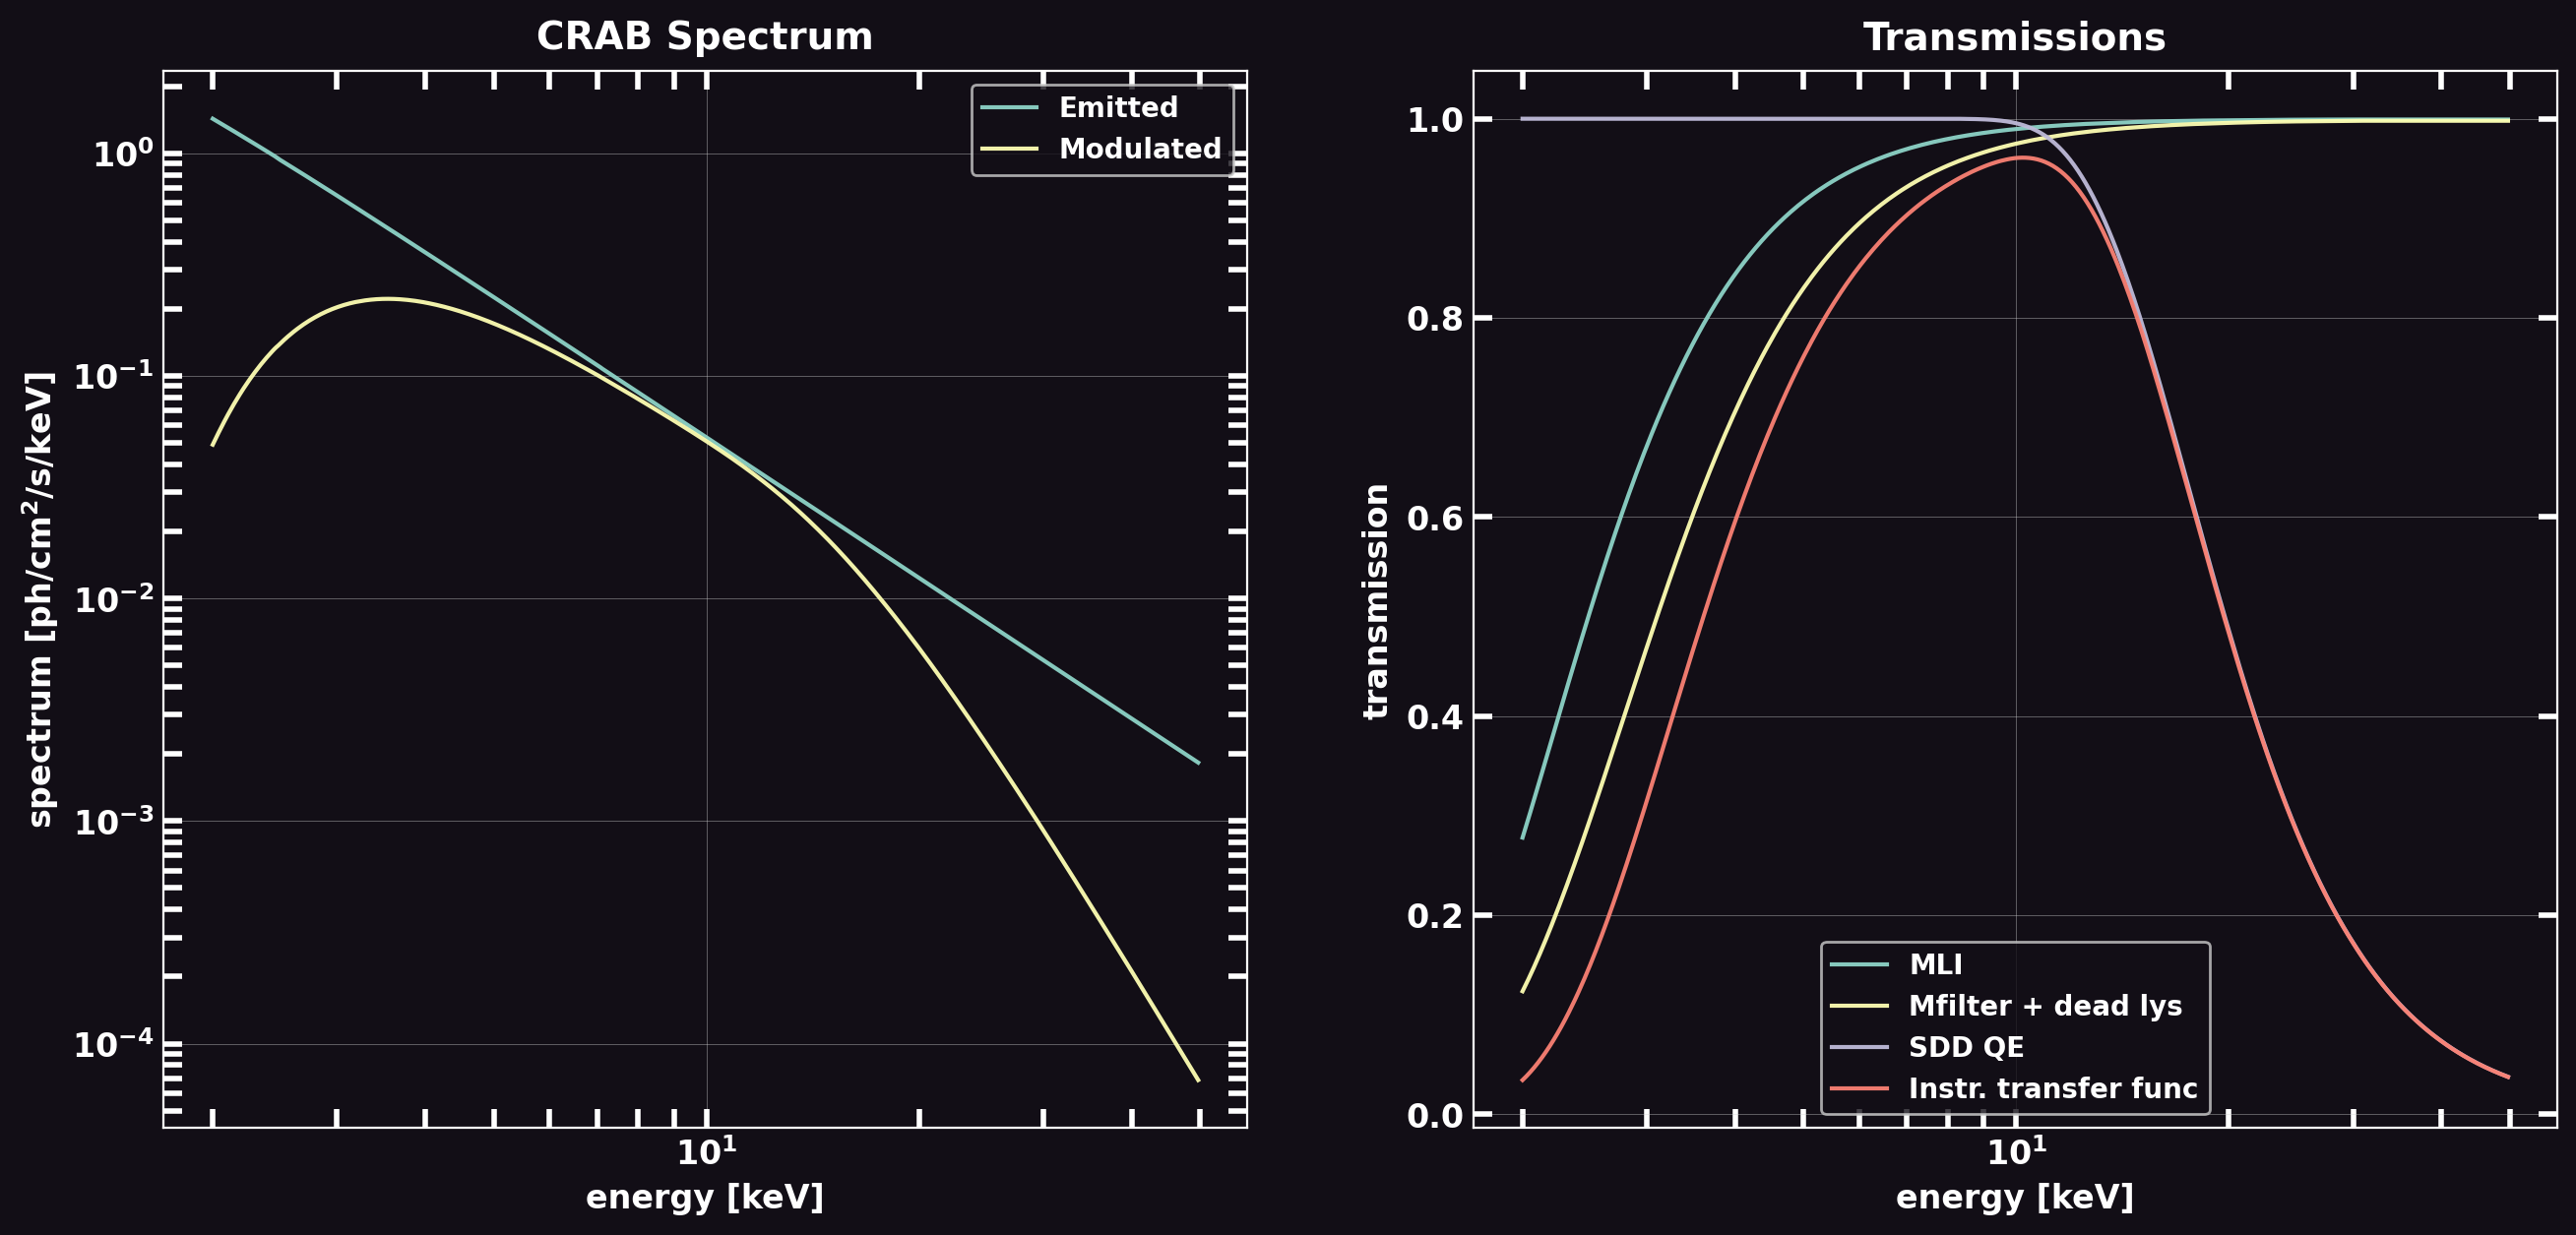

## USING BULK MASK with 1.5 mm cover ##
Energy range: (2.0, 50.0) keV at (40.0, 40.0) deg
  - Source avg flux: 1.2794 ph/cm2/s
  - Source obs counts in 1.0 ks: 6009 +/- 77 ph



In [11]:
type AngularCoords = tuple[float, float]   # camera local-frame angular coords (fine, coarse) in [deg]
type EnergyRange = tuple[float, float]     # photons energy range (min, max) in [keV]

def plot_spectr(
    sourceID: str,
    coords: AngularCoords,
    energy_bins: NDArray,
    spectrum: NDArray,
    transfunc: NDArray,
    mli: NDArray,
    dl_filter: NDArray,
    matten: NDArray,
) -> None:
    """Plots source spectrum and instr. modulations."""
    polar_angle = np.deg2rad(compute_theta(*coords))
    exp = 1 / np.cos(polar_angle)
    det_qe = get_detector_QE(
        matten=matten,
        angle=polar_angle,
    )
    ds.plot(
        dmaps=(
            ds.map4plot(
                arrs=(spectrum, transfunc * spectrum),
                title=f'{sourceID.upper()} Spectrum',
                x=energy_bins[:-1],
                xlabel='energy [keV]',
                ylabel='spectrum [ph/cm$^{2}$/s/keV]',
                labels=('Emitted', 'Modulated'),
                yscale='log',
                xscale='log',
            ),
            ds.map4plot(
                arrs=(
                    np.pow(mli, exp), np.pow(dl_filter, exp), det_qe, transfunc,
                ),
                title='Transmissions',
                x=energy_bins[:-1],
                xlabel='energy [keV]',
                ylabel='transmission',
                labels=(
                    'MLI', 'Mfilter + dead lys', 'SDD QE', 'Instr. transfer func',
                ),
                xscale='log',
            ),
        ),
        ncols=2,
    )
    return None

def compute_source_avgflux(
    sourceID: str,
    coords: AngularCoords,
    energy_range: EnergyRange,
    catalogue: FITS_rec,
    show_spectr: bool = False,
) -> None:
    """
    Computes the source average flux measured by a LEM-X camera in [ph/cm2/s].
    """
    # extract source spectrum and energy bins
    energy_bins, spectrum = extract_spectrum(catalogue, sourceID, energy_range)
    # modulate source spectrum with instrumental transfer func
    mli, dl_filter, matten = config_transmissions(energy_bins)
    transfunc = get_instr_transfer_func(mli, dl_filter, matten, coords)
    # show spectrum plot
    if show_spectr:
        plot_spectr(
            sourceID, coords, energy_bins, spectrum,
            transfunc, mli, dl_filter, matten,
        )
    return integrate_spectrum(transfunc * spectrum, energy_bins)

#def compute_source_avgflux(
#    sourceID: str,
#    coords: AngularCoords,
#    energy_range: EnergyRange,
#    catalogue: FITS_rec,
#) -> None:
#    """
#    Computes the source average flux measured by a LEM-X camera in [ph/cm2/s].
#    """
#    # extract source spectrum and energy bins
#    bins, _spectrum = extract_spectrum(catalogue, sourceID, energy_range)
#    _energy_bins = np.log(np.logspace(*energy_range, int(5e3) + 1, base=np.e))
#    lims = (_energy_bins >= bins[0]) & (_energy_bins <= bins[-2])
#    energy_bins = _energy_bins[lims]
#    spectrum = interp(bins[:-1], _spectrum, energy_bins)[:-1]
#    # modulate source spectrum with instrumental transfer func
#    mli, dl_filter, matten = config_transmissions(energy_bins)
#    transfunc = get_instr_transfer_func(mli, dl_filter, matten, coords)
#    return integrate_spectrum(transfunc * spectrum, energy_bins)



# init source info
sourceID: str = 'crab'                      # source ID in the record
energy_range: EnergyRange = (2.0, 50.0)     # specifies photons energy range [keV]

coords: AngularCoords = (40.0, 40.0)     # [deg]
exposure: float = 1e3                  # [s]

avg_flux: float = compute_source_avgflux(sourceID, coords, energy_range, catalogue, True)   # [ph/cm2/s]
counts: int = compute_source_counts(wfm, coords, avg_flux, exposure)                        # [ph]
print(
    f'Energy range: {energy_range} keV at {coords} deg\n'
    f'  - Source avg flux: {avg_flux:.4f} ph/cm2/s\n'
    f'  - Source obs counts in {exposure/1e3} ks: {counts} +/- {int(np.sqrt(counts))} ph\n'
)

In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Container:
    """Info container for source analysis."""
    sourceID: str
    coords: AngularCoords
    exposure: float
    tot_avgflux: float
    tot_counts: float
    ebands: tuple[EnergyRange, ...]
    flxs: list[float]
    cts: list[float]

def source_verbose(data: Container) -> None:
    """Prints out info on observed source photons."""
    print(
        f'## Source: {data.sourceID} at {data.coords} deg\n'
        f'  - total avg flux in (2.0, 50.0) keV: {data.tot_avgflux:.4f} ph/cm2/s\n'
        f'  - total counts in (2.0, 50.0) keV ({data.exposure/1e3} ks): {data.tot_counts} ph\n'
    )
    for idx, eband in enumerate(data.ebands):
        print(
            f'Energy band: {eband} keV\n'
            f'  - avg flux: {data.flxs[idx]:.4f} ph/cm2/s\n'
            f'  - obs counts in {data.exposure/1e3} ks: {data.cts[idx]} ph\n'
            f'  - counts fraction: {data.cts[idx] * 100 / data.tot_counts:.4f} %\n'
        )
    print(
        f'## Benchmark Error\n'
        f'Total avg flux in energy bands: {sum(data.flxs):.4f} ph/cm2/s\n'
        f'Total counts in energy bands: {sum(data.cts)} ph\n'
        f'Reconstr photons wrt full band: {sum(data.cts) * 100 / data.tot_counts:.4f} %\n'
    )

def analyse_counts(
    camera: CodedMaskCamera,
    catalogue: FITS_rec,
    sourceID: str,
    coords: AngularCoords,
    energy_bands: EnergyRange | tuple[EnergyRange, ...],
    exposure: float = 1e3,
) -> Container:
    """
    Analyses the detected photons from input source in the
    specified energy bands and from the given direction,
    finally retrieving the respective fractional counts.
    """
    avg_fluxs: list[float] = []
    cts: list[float] = []
    # compute total source counts in full LEM-X band [2, 50] keV
    tot_avgflux = compute_source_avgflux(sourceID, coords, (2.0, 50.0), catalogue)
    tot_counts: int = compute_source_counts(camera, coords, tot_avgflux, exposure)
    # compute source counts in specific energy band
    energy_bands_ = (energy_bands,) if isinstance(energy_bands[0], float) else energy_bands
    for eband in energy_bands_:
        _avg_flux: float = compute_source_avgflux(sourceID, coords, eband, catalogue)
        _counts: int = compute_source_counts(wfm, coords, _avg_flux, exposure)
        avg_fluxs.append(_avg_flux)
        cts.append(_counts)
    
    data: Container = Container(
        sourceID, coords, exposure, tot_avgflux,
        tot_counts, energy_bands_, avg_fluxs, cts,
    )
    return data


sourceID: str = 'crab'
coords: AngularCoords = (40.0, 40.0)      # [deg]
bands: tuple[EnergyRange, ...] = (
    (2.0, 5.0), (5.0, 10.0), (10.0, 20.0), (20.0, 50.0),
)
data = analyse_counts(wfm, catalogue, sourceID, coords, bands)
source_verbose(data)

## Source: crab at (40.0, 40.0) deg
  - total avg flux in (2.0, 50.0) keV: 1.2794 ph/cm2/s
  - total counts in (2.0, 50.0) keV (1.0 ks): 6009 ph

Energy band: (2.0, 5.0) keV
  - avg flux: 0.5426 ph/cm2/s
  - obs counts in 1.0 ks: 2548 ph
  - counts fraction: 42.4031 %

Energy band: (5.0, 10.0) keV
  - avg flux: 0.4844 ph/cm2/s
  - obs counts in 1.0 ks: 2275 ph
  - counts fraction: 37.8599 %

Energy band: (10.0, 20.0) keV
  - avg flux: 0.2147 ph/cm2/s
  - obs counts in 1.0 ks: 1008 ph
  - counts fraction: 16.7748 %

Energy band: (20.0, 50.0) keV
  - avg flux: 0.0316 ph/cm2/s
  - obs counts in 1.0 ks: 148 ph
  - counts fraction: 2.4630 %

## Benchmark Error
Total avg flux in energy bands: 1.2732 ph/cm2/s
Total counts in energy bands: 5979 ph
Reconstr photons wrt full band: 99.5007 %



In [13]:
@dataclass(frozen=True)
class SourceType:
    ID: str
    code: str
    idx: float

def define_source(data: FITS_rec, sourceID: str) -> SourceType:
    """Initialises a SourceType instance with info on input source."""
    src: FITS_rec = source_catalogue_data(sourceID, data)
    return SourceType(
        sourceID, src['FORMULA'], src['INDEX'],
    )

def verbose(
    sources: SourceType | tuple[SourceType, ...],
    data: Container | tuple[Container, ...],
) -> None:
    """Prints out sources obs counts in given energy bands."""
    sources_ = (sources,) if isinstance(sources, SourceType) else sources
    data_ = (data,) if isinstance(data, Container) else data
    for src, cnt in zip(sources_, data_):
        outs: tuple[str] = tuple(
            f'{eband} keV: {cnt.cts[idx]} ph ({cnt.cts[idx] * 100 / cnt.tot_counts:.2f}%)  |  '
            for idx, eband in enumerate(cnt.ebands)
        )
        coords_: str = f'({cnt.coords[0]:.2f}, {cnt.coords[1]:.2f})'
        print(
            f'\nSource: {src.ID.upper()}  |  CODE: {src.code}, INDEX: {src.idx:.2f}\n'
            f'Coords: {coords_} deg, exposure: {cnt.exposure/1e3} ks\n'
            f'Observed counts: {cnt.tot_counts} ph\n{''.join(outs)[:-5]}'
        )
    return None


# obs counts from sources at fixed coords (w different spectrum)
sourceIDs: tuple[str, ...] = (
    'crab', 'grs1915+105', 'cygx1', 'scox1', 'gx5-1', 'gx17+2', 'gx354-0', 'herx1',
)
sources: tuple[SourceType, ...] = tuple(
    define_source(catalogue, src) for src in sourceIDs
)
coords: AngularCoords = (21.0, 12.0)      # [deg]
bands: tuple[EnergyRange, ...] = (
    (2.0, 5.0), (5.0, 7.0), (7.0, 10.0), (10.0, 50.0), (20.0, 50.0),
)

data: tuple[Container] = tuple(
    analyse_counts(wfm, catalogue, src.ID, coords, bands) for src in sources
)
verbose(sources, data)


Source: CRAB  |  CODE: wabs*powerlaw, INDEX: 2.10
Coords: (21.00, 12.00) deg, exposure: 1.0 ks
Observed counts: 76151 ph
(2.0, 5.0) keV: 37956 ph (49.84%)  |  (5.0, 7.0) keV: 14716 ph (19.32%)  |  (7.0, 10.0) keV: 11459 ph (15.05%)  |  (10.0, 50.0) keV: 11466 ph (15.06%)  |  (20.0, 50.0) keV: 1234 ph (1.62%)

Source: GRS1915+105  |  CODE: wabs*powerlaw, INDEX: 1.50
Coords: (21.00, 12.00) deg, exposure: 1.0 ks
Observed counts: 64187 ph
(2.0, 5.0) keV: 21893 ph (34.11%)  |  (5.0, 7.0) keV: 12645 ph (19.70%)  |  (7.0, 10.0) keV: 12182 ph (18.98%)  |  (10.0, 50.0) keV: 16993 ph (26.47%)  |  (20.0, 50.0) keV: 2602 ph (4.05%)

Source: CYGX1  |  CODE: wabs*powerlaw, INDEX: 1.70
Coords: (21.00, 12.00) deg, exposure: 1.0 ks
Observed counts: 35135 ph
(2.0, 5.0) keV: 13054 ph (37.15%)  |  (5.0, 7.0) keV: 7182 ph (20.44%)  |  (7.0, 10.0) keV: 6483 ph (18.45%)  |  (10.0, 50.0) keV: 8148 ph (23.19%)  |  (20.0, 50.0) keV: 1115 ph (3.17%)

Source: SCOX1  |  CODE: wabs*bremss, INDEX: 3.40
Coords: (21.

In [14]:
# obs counts from sources w different spectrum and breaking index

def selector(data: FITS_rec, cond: NDArray) -> FITS_rec:
    return data[cond]

mask_code = lambda code: (catalogue['CODE'] == code)
mask_idx = lambda idx: np.isclose(catalogue['INDEX'], idx, atol=1e-3)
mask_avgflux = lambda flx: (catalogue['AVG_FLUX'] > flx)

def stack_idxs(data: FITS_rec, *idxs: float) -> NDArray:
    """Joins multiple breaking idx masks for the catalogue."""
    mask: NDArray = np.zeros(len(data), dtype=bool)
    for idx in idxs:
        mask |= mask_idx(idx)
    return mask

def gen_coords(n: int) -> tuple[AngularCoords, ...]:
    """Generates `n` angular coords [deg] in the camera local-frame."""
    fov = (0.0, 42.0)
    gen = lambda: (np.random.uniform(*fov), np.random.uniform(*fov))
    return tuple(gen() for _ in range(n))


code: int = 1

_idxs: NDArray = selector(catalogue, mask_code(code))['INDEX']
print(
    f'Total sources with CODE = {code}: {len(_idxs)}\n'
    f'Available breaking indexes values:\n {np.unique(_idxs)}'
)

Total sources with CODE = 1: 219
Available breaking indexes values:
 [1.  1.2 1.3 1.4 1.5 1.6 1.7 1.8 2.  2.1 2.2 2.7 2.9 4.2 4.3]


In [15]:
idxs: float | tuple[float, ...] = (
    2.1,
)
min_avgflx: float = 6e-3

cond1 = (
    mask_code(code) & mask_avgflux(min_avgflx)
)
cond2 = stack_idxs(catalogue, *idxs)

srcs: NDArray = selector(catalogue, cond1 & cond2)['ID']
print(
    f'Available Sources [avg flux > {min_avgflx} ph/cm2/s]: {len(srcs)}\n\n'
    f'{srcs}\n'
)

Available Sources [avg flux > 0.006 ph/cm2/s]: 100

['1e1740.7-2942' '1e2259.0+5836' '1es0821-426' '1es1959+650' '3c129.cg'
 '3c273' 'algol' 'axj1820.5-1434' 'casa' 'cen.cg' 'cena' 'coma.cg' 'crab'
 'cyga' 'etacar' 'exhya' 'exo0748-676' 'exo1745-248' 'exo2030+375'
 'gammacas' 'gctr_diffuse' 'gcx-1' 'groj1744-28' 'groj1750-27'
 'grs1739-278' 'grs1747-312' 'grs1758-258' 'h1743-322' 'hetej1900.1-2455'
 'ic4329a' 'ic443snr' 'igrj08408-4503' 'igrj16418-4532' 'igrj16479-4514'
 'igrj17091-3624' 'igrj17098-3626' 'igrj17354-3255' 'igrj17407-2808'
 'igrj17473-2721' 'igrj17488-3253' 'igrj18027-2017' 'igrj1914+0951'
 'ks1730-312' 'm87' 'maxij0556-332' 'maxij1409-619' 'maxij1659-152'
 'mkn421' 'mkn501' 'ngc1275.cg' 'ngc4151' 'oph.cg' 'puppisa'
 'rxj1708.9-3219' 'rxj1718.4-4029' 'saxj1712.6-3739' 'saxj1752.3-3128'
 'saxj1753.5-2349' 'saxj1805.5-2031' 'saxj1810.8-2609' 'saxj1818.6-1703'
 'sl1746-331' 'ss433' 'swiftj1753.5-012' 'swiftj1756.9-250' 'trap.cg'
 'tychosnr' 'v0332+53' 'v4641sgr' 'velapulsar

In [16]:
sources: tuple[SourceType, ...] = tuple(
    define_source(catalogue, src) for src in srcs
)
coords: tuple[AngularCoords, ...] = gen_coords(len(sources))
#coords: tuple[AngularCoords, ...] = (
#    (0.0, 0.0), (20.0, 20.0), (20.0, 5.0), (5.0, 20.0), (35.0, 35.0),
#)
bands: tuple[EnergyRange, ...] = (
    (2.0, 5.0), (5.0, 7.0), (7.0, 10.0), (10.0, 20.0), (20.0, 50.0),
)

data: tuple[Container] = tuple(
    analyse_counts(wfm, catalogue, src.ID, crds, bands, exposure=1e5) for src, crds in zip(sources, coords)
)
#verbose(sources, data)

In [17]:
# obs counts from sources w different spectrum and breaking index - analyse counts distr in energy bands
type CountsDmap = dict[str, tuple[SourceType] | dict[tuple[EnergyRange], tuple[float]]]

def organise_counts(
    containers: Container | tuple[Container, ...],
    catalogue: FITS_rec,
) -> CountsDmap:
    """
    Takes counts fracts inside containers and organises them per energy band.
    The output dict is built to compare the fractional counts for each source. 

    NOTE: No check on energy bands, they must be the same for ALL containers.
    """
    containers_ = (containers,) if isinstance(containers, Container) else containers
    sources: tuple[SourceType, ...] = tuple(
        define_source(catalogue, cnt.sourceID) for cnt in containers_
    )
    # NOTE: assuming same energy bands for ALL containers
    ebands: tuple[EnergyRange, ...] = containers_[0].ebands
    ebands_dmap: dict[EnergyRange, tuple[float, ...]] = {
        eband: tuple(cnt.cts[idx] * 100 / cnt.tot_counts for cnt in containers_)
        for idx, eband in enumerate(ebands)
    }
    # source IDs and fract counts values are linked
    dmap: CountsDmap = {
        'sources': sources,
        'ebands': ebands_dmap,  
    }
    return dmap

def get_stats(
    sequence: tuple[float, ...],
    stat_thres: int = 3,
) -> tuple[float, float]:
    """Computes the median and std of the input sequence of values."""
    if len(sequence) < stat_thres:
        raise ValueError(
            f'Input sequence must contain at least {stat_thres} elements.'
        )
    seq = np.array(sequence)
    return np.median(seq), np.std(seq)

def cts_verbose(cts_dmap: CountsDmap) -> None:
    """Prints out info on counts fracts per energy bands."""
    for eband, values in cts_dmap['ebands'].items():
        median, std = get_stats(values)
        mean: float = sum(values) / len(values)
        print(
            f'Energy band: {eband} keV  |  median: {median:.3f}%, mean: {mean:.3f}%, std: {std:.3f} perc points\n'
        )
    return None


cts_dmap = organise_counts(data, catalogue)
cts_verbose(cts_dmap)

Energy band: (2.0, 5.0) keV  |  median: 47.772%, mean: 47.650%, std: 2.314 perc points

Energy band: (5.0, 7.0) keV  |  median: 19.732%, mean: 19.751%, std: 0.448 perc points

Energy band: (7.0, 10.0) keV  |  median: 15.526%, mean: 15.551%, std: 0.533 perc points

Energy band: (10.0, 20.0) keV  |  median: 14.340%, mean: 14.393%, std: 1.053 perc points

Energy band: (20.0, 50.0) keV  |  median: 1.829%, mean: 1.854%, std: 0.250 perc points



In [18]:
# ----------------------------------------------------------------------------------------------------
# - WM benchmark sim (in `demo_source_PSF.ipynb`) confirms that sources with Crab spectra at
#   different coords and with different avg fluxes have approx the same cts:
#       * s17
#       (2.0, 5.0)keV: 47.12%  |  (5, 10)kev : 35.92%  |  (10, 20)keV: 14.60%  |  (20, 50)kev : 1.97%
#       * s23 -- ~same coords as scox1 --
#       (2.0, 5.0)keV: 48.88%  |  (5, 10)kev : 35.17%  |  (10, 20)keV: 13.84%  |  (20, 50)kev : 1.65%
#       * s8
#       (2.0, 5.0)keV: 44.98%  |  (5, 10)kev : 36.61%  |  (10, 20)keV: 15.83%  |  (20, 50)kev : 2.21%
# ----------------------------------------------------------------------------------------------------

- Now that we established a similar behaviour for Crab-like sources, let's try to fit the trend of the counts percentage emission wrt selected energy bands

- Since the counts percentage seems stable wrt the sources location, let's assume a source at ~15 deg wrt the camera optical axis

- Moreover, since in the band [20.0, 50.0] keV the detected photons represent the ~2% of the total emission, let's focus on the [2.0, 20.0] keV band

In [104]:
source: str = 'crab'
localcoords: AngularCoords = (15.0, 15.0)  # [deg]

estep: float = 0.1  # [keV]
ebands: tuple[EnergyRange, ...] = tuple(
    (float(a), float(a + estep)) for a in np.arange(2.0, 20.0, estep)
)
data: Container = analyse_counts(wfm, catalogue, source, localcoords, ebands, exposure=1e5)
cts_dmap: CountsDmap = organise_counts(data, catalogue)

In [108]:
points[:, 1].sum()

np.float64(61.74601058623729)

## Fit results
  * x0 = 1.925495 +/- 0.067274
  * a = 2.682615 +/- 0.103140
  * b = 0.499387 +/- 0.087533
  * c = 0.530655 +/- 0.033351
Covar matrix:
[[ 0.00452577 -0.00375588 -0.00533363 -0.00169814]
 [-0.00375588  0.0106378   0.00670218  0.00309653]
 [-0.00533363  0.00670218  0.007662    0.00272185]
 [-0.00169814  0.00309653  0.00272185  0.00111231]]


/tmp/ipykernel_14598/2165752012.py:46: RuntimeWarning: divide by zero encountered in divide
  arrs=(points[:, 1] - mod_kernel(points[:, 0], *popt)) / points[:, 1],


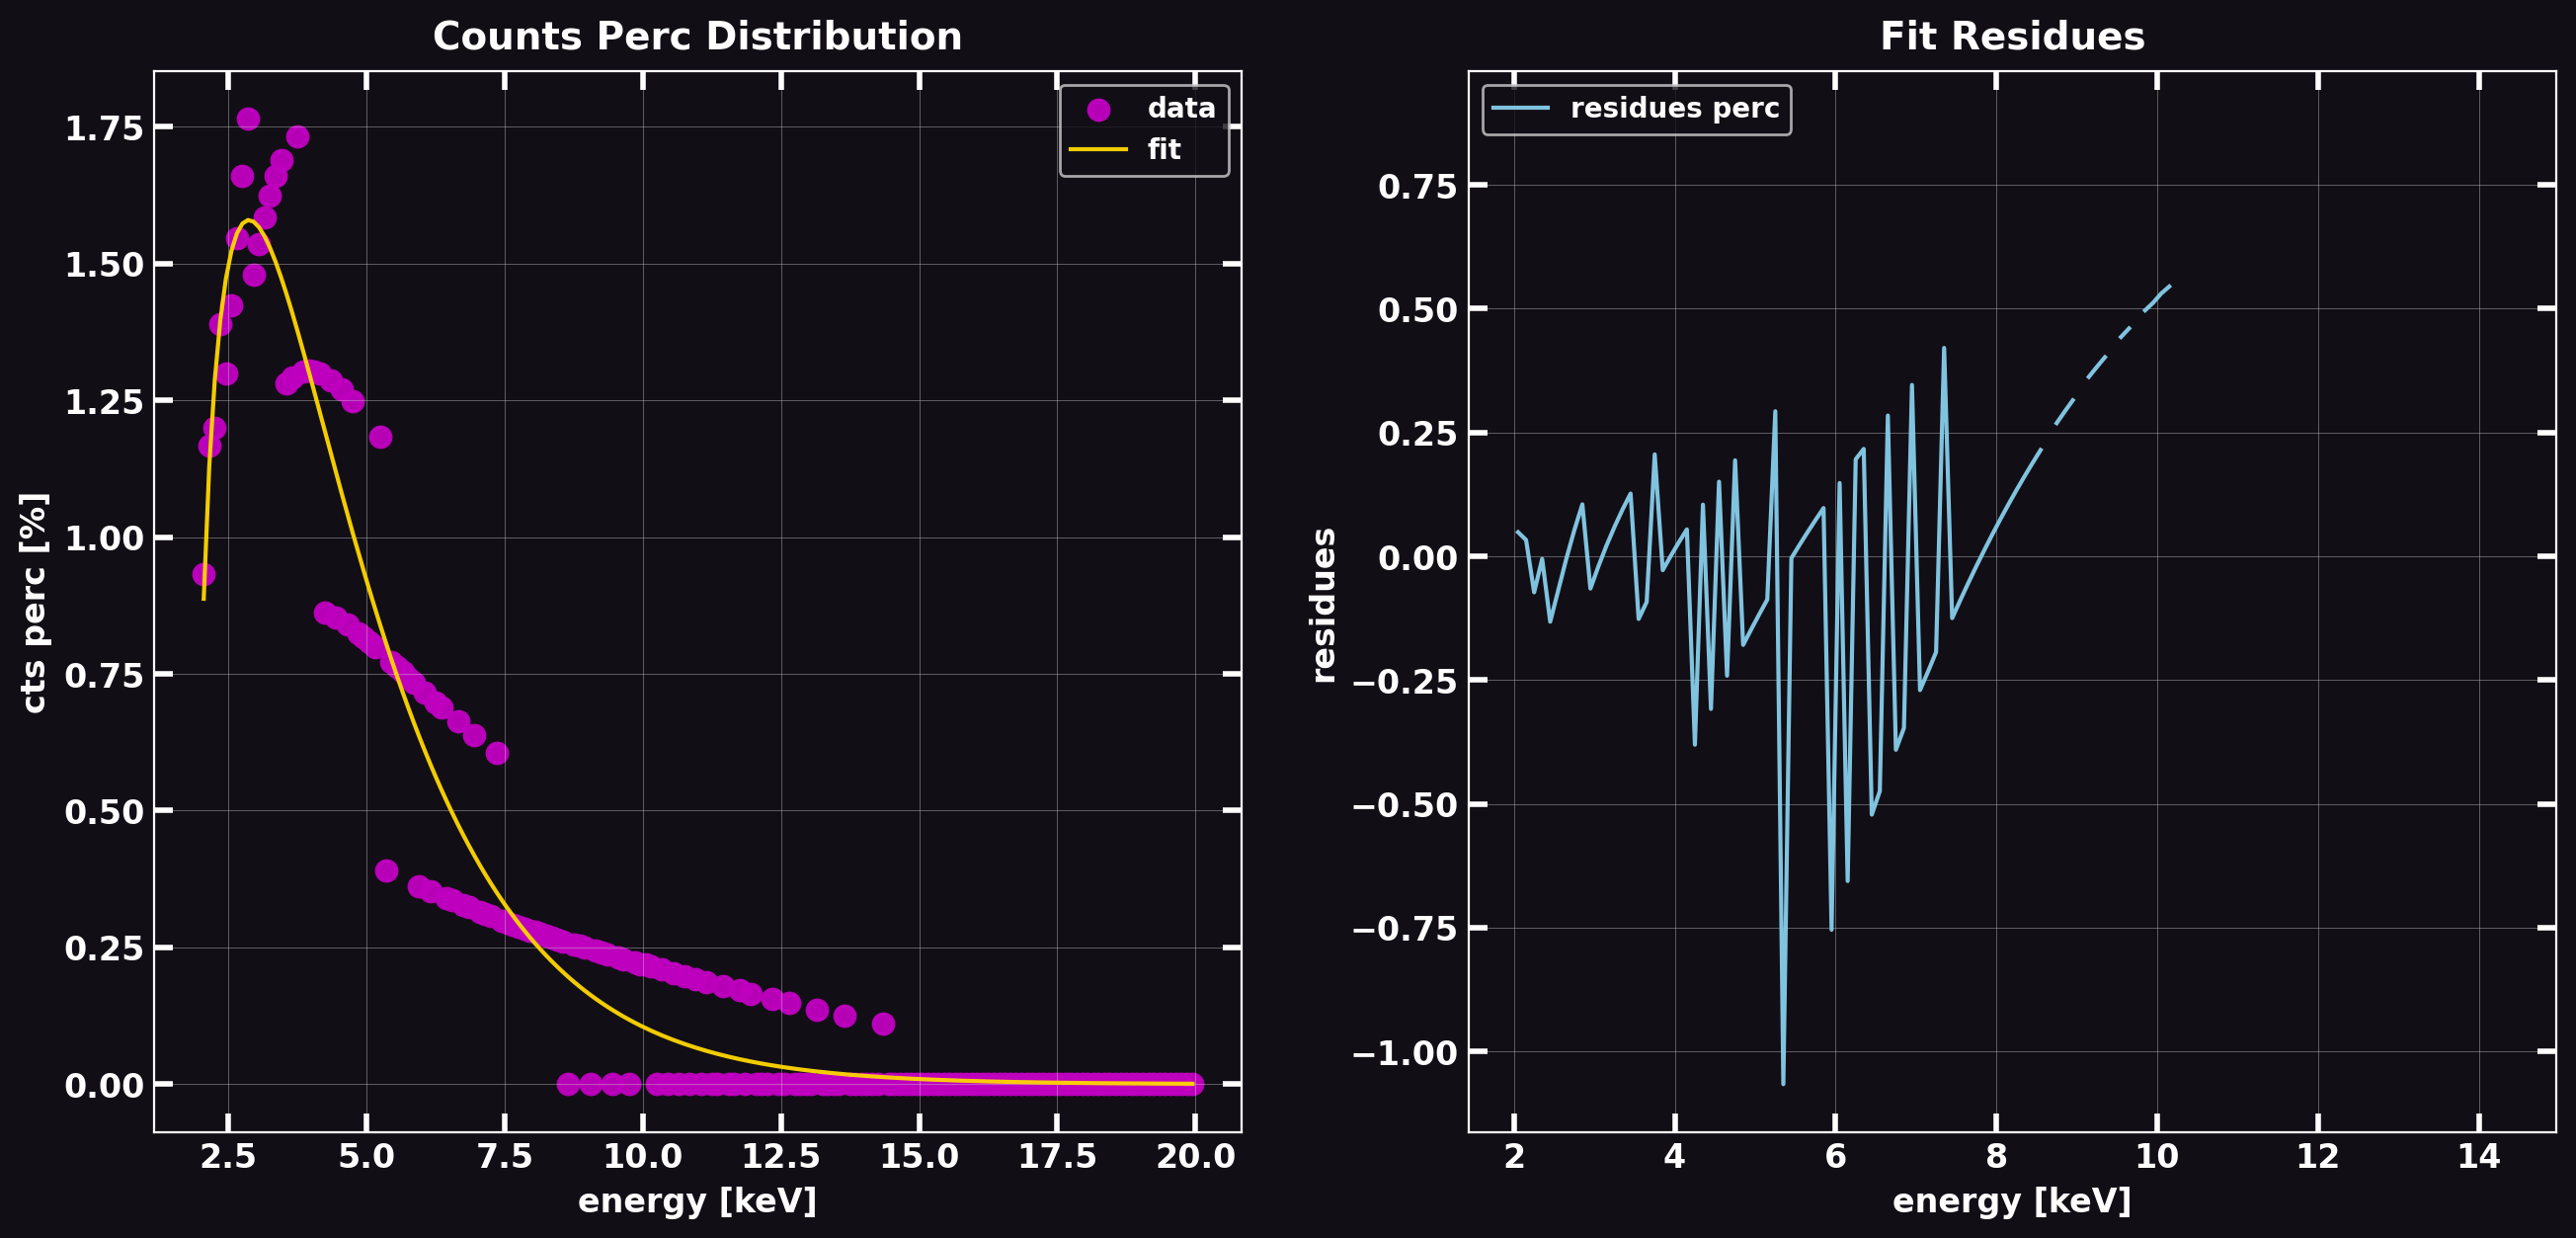

In [105]:
from scipy.optimize import curve_fit

type Point = tuple[float, float]

def mod_kernel(x: NDArray, x0: float, a: float, b: float, c: float) -> NDArray:
    """Custom exp - power law function."""
    x_ = x - x0
    return a * np.pow(x_, b) * np.exp(-c * x_)

def compute_popt_error(covar: NDArray) -> NDArray:
    """Computes the std error of the fitted params from covar matrix."""
    return np.sqrt(np.diag(covar))


evals: tuple[float, ...] = tuple(sum(eband) / 2 for eband in ebands)
points: NDArray = np.array(
    tuple((e, perc[0]) for e, perc in zip(evals, cts_dmap['ebands'].values()))
)

popt, pcov = curve_fit(
    mod_kernel, points[:, 0], points[:, 1],
    p0=np.array([1.0, 8.0, 0.5, 0.5]), bounds=((0.0, 0.0, 0.0, 0.0), (2.0, 15.0, 2.0, 2.0)),
)
stds: NDArray = compute_popt_error(pcov)

print('## Fit results')
_fit_params: tuple[str, ...] = ('x0', 'a', 'b', 'c')
for idx, (c, err) in enumerate(zip(popt, stds)):
    print(f'  * {_fit_params[idx]} = {c:.6f} +/- {err:.6f}')
print(f'Covar matrix:\n{pcov}')

get_pred = lambda x: mod_kernel(x, *popt)
ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=(points[:, 1], get_pred(points[:, 0])),
            title='Counts Perc Distribution',
            xlabel='energy [keV]',
            ylabel='cts perc [%]',
            labels=('data', 'fit'),
            x=points[:, 0],
            color=('m', 'Gold'),
            style=('scatter', 'plot')
        ),
        ds.map4plot(
            arrs=(points[:, 1] - mod_kernel(points[:, 0], *popt)) / points[:, 1],
            title='Fit Residues',
            xlabel='energy [keV]',
            ylabel='residues',
            x=points[:, 0],
            labels='residues perc',
            color='SkyBlue',
        ),
    ),
    ncols=2,
)

In [106]:
evals: NDArray = np.linspace(2.0, 5.0, int(1e4 + 1))

integrate(get_pred(evals)[:-1], np.diff(evals))

np.float64(3.9441928901659002)